In [3]:
import pandas as pd 
import numpy as np

In [4]:
df_levels_complete = pd.read_csv('/Users/baselhussein/Projects/impossible_goals/agg/data/id_levels_complete.csv')
df_goal_approach_sequencing = pd.read_csv('/Users/baselhussein/Projects/impossible_goals/agg/data/goal_approach_levels.csv')

In [5]:
df_levels_complete

,ID,levels_complete,len_levels_complete
0,1,"['0level:baba is you', '1level:where do i go?'...",7
1,2,"['0level:baba is you', '1level:where do i go?'...",35
2,3,"['0level:baba is you', '1level:where do i go?'...",8
3,5,"['0level:baba is you', '1level:where do i go?'...",9
4,6,"['0level:baba is you', '1level:where do i go?'...",36
...,...,...,...
180,254,"['0level:baba is you', '1level:where do i go?'...",9
181,255,"['0level:baba is you', '1level:where do i go?'...",23
182,256,"['0level:baba is you', '1level:where do i go?'...",9
183,257,"['236level:changeless', '136level:jelly throne...",19


In [6]:
df_levels_complete.describe()

,ID,len_levels_complete
count,185.000000,185.000000
mean,143.821622,27.897297
std,75.310990,14.463043
min,1.000000,1.000000
25%,78.000000,18.000000
50%,155.000000,27.000000
75%,209.000000,36.000000
max,258.000000,92.000000


In [7]:
df_goal_approach_sequencing

,ID,approach
0,6,low-returns_fast-reframe -> low-returns_fast-r...
1,12,low-returns_fast-reframe -> low-returns_slow-r...
2,22,low-returns_fast-reframe -> low-returns_fast-r...
3,23,low-returns_fast-reframe -> low-returns_slow-r...
4,26,low-returns_fast-reframe -> low-returns_slow-r...
...,...,...
74,241,high-returns_fast-reframe -> low-returns_fast-...
75,242,low-returns_fast-reframe -> low-returns_slow-r...
76,248,low-returns_fast-reframe -> low-returns_fast-r...
77,251,low-returns_fast-reframe -> low-returns_fast-r...


In [2]:
print(df_goal_approach_sequencing['approach'].unique())

In [1]:
# Add new column based on condition
df_goal_approach_sequencing['approach_condition'] = (df_goal_approach_sequencing['approach']
                                            .apply(lambda x: 
                                                   'condition_a' if x == 'low-returns_fast-reframe -> low-returns_fast-reframe -> low-returns_fast-reframe' 
                                                   else 'condition_b'))

In [10]:
df_goal_approach_sequencing

,ID,approach,approach_condition
0,6,low-returns_fast-reframe -> low-returns_fast-r...,condition_a
1,12,low-returns_fast-reframe -> low-returns_slow-r...,condition_b
2,22,low-returns_fast-reframe -> low-returns_fast-r...,condition_b
3,23,low-returns_fast-reframe -> low-returns_slow-r...,condition_b
4,26,low-returns_fast-reframe -> low-returns_slow-r...,condition_b
...,...,...,...
74,241,high-returns_fast-reframe -> low-returns_fast-...,condition_b
75,242,low-returns_fast-reframe -> low-returns_slow-r...,condition_b
76,248,low-returns_fast-reframe -> low-returns_fast-r...,condition_a
77,251,low-returns_fast-reframe -> low-returns_fast-r...,condition_b


In [11]:
# combine 

In [12]:
df_combined = pd.merge(df_levels_complete, df_goal_approach_sequencing, on='ID', how='inner')

In [13]:
df_combined

,ID,levels_complete,len_levels_complete,approach,approach_condition
0,6,"['0level:baba is you', '1level:where do i go?'...",36,low-returns_fast-reframe -> low-returns_fast-r...,condition_a
1,12,"['0level:baba is you', '1level:where do i go?'...",37,low-returns_fast-reframe -> low-returns_slow-r...,condition_b
2,22,"['0level:baba is you', '1level:where do i go?'...",24,low-returns_fast-reframe -> low-returns_fast-r...,condition_b
3,23,"['0level:baba is you', '1level:where do i go?'...",31,low-returns_fast-reframe -> low-returns_slow-r...,condition_b
4,26,"['0level:baba is you', '1level:where do i go?'...",38,low-returns_fast-reframe -> low-returns_slow-r...,condition_b
...,...,...,...,...,...
74,241,"['0level:baba is you', '1level:where do i go?'...",34,high-returns_fast-reframe -> low-returns_fast-...,condition_b
75,242,"['0level:baba is you', '1level:where do i go?'...",37,low-returns_fast-reframe -> low-returns_slow-r...,condition_b
76,248,"['0level:baba is you', '1level:where do i go?'...",22,low-returns_fast-reframe -> low-returns_fast-r...,condition_a
77,251,"['0level:baba is you', '1level:where do i go?'...",31,low-returns_fast-reframe -> low-returns_fast-r...,condition_b


In [14]:
df_stats = df_combined[['len_levels_complete', 'approach_condition']]

In [15]:
df_stats

,len_levels_complete,approach_condition
0,36,condition_a
1,37,condition_b
2,24,condition_b
3,31,condition_b
4,38,condition_b
...,...,...
74,34,condition_b
75,37,condition_b
76,22,condition_a
77,31,condition_b


In [16]:
# def remove_outliers(df_stats, threshold=3):
#     """
#     Remove outliers that are more than `threshold` standard deviations from the mean.
#     """
#     for column in df_stats.columns:
#         mean = df_stats[column].mean()
#         std = df_stats[column].std()
#         lower_bound, upper_bound = mean - threshold * std, mean + threshold * std
#         df_stats = df_stats[(df_stats[column] >= lower_bound) & (df_stats[column] <= upper_bound)]
#     return df_stats

In [17]:
# df_stats_no_outliers = remove_outliers(df_stats)

In [18]:
df_stats.describe()

,len_levels_complete
count,79.000000
mean,37.316456
std,12.113295
min,20.000000
25%,29.500000
50%,36.000000
75%,41.500000
max,92.000000


In [19]:
df_stats

,len_levels_complete,approach_condition
0,36,condition_a
1,37,condition_b
2,24,condition_b
3,31,condition_b
4,38,condition_b
...,...,...
74,34,condition_b
75,37,condition_b
76,22,condition_a
77,31,condition_b


In [37]:
average_by_condition = df_stats.groupby('approach_condition')['len_levels_complete'].mean()
average_by_condition

approach_condition
condition_a    42.1875
condition_b    34.0000
Name: len_levels_complete, dtype: float64

In [21]:
condition_a = df_stats[df_stats['approach_condition'] == 'condition_a']['len_levels_complete']
condition_b = df_stats[df_stats['approach_condition'] == 'condition_b']['len_levels_complete']

In [22]:
type(condition_a)

pandas.core.series.Series

In [23]:
len(condition_a)

32

In [32]:
len(condition_b)

47

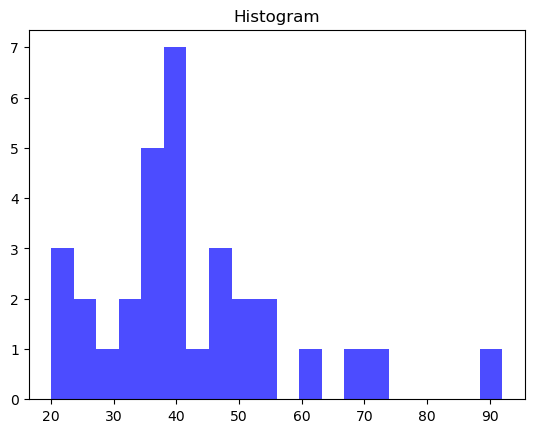

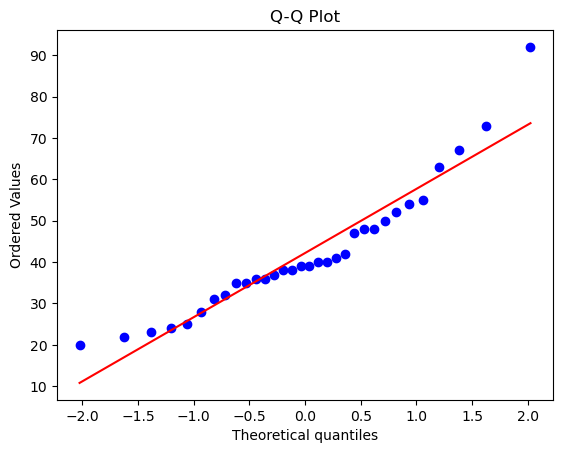

Shapiro-Wilk Test: Stat=0.9137343764305115, P-value=0.01410922221839428
Kolmogorov-Smirnov Test: Stat=0.16101816850760864, P-value=0.34078773730691225


In [35]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Histogram
plt.hist(condition_a, bins=20, alpha=0.7, color='blue')
plt.title('Histogram')
plt.show()

# Q-Q plot
stats.probplot(condition_a, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

# Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(condition_a)
print(f"Shapiro-Wilk Test: Stat={shapiro_stat}, P-value={shapiro_p}")

# Kolmogorov-Smirnov test (comparing against a normal distribution)
ks_stat, ks_p = stats.kstest(condition_a, 'norm', args=(condition_a.mean(), condition_a.std()))
print(f"Kolmogorov-Smirnov Test: Stat={ks_stat}, P-value={ks_p}")

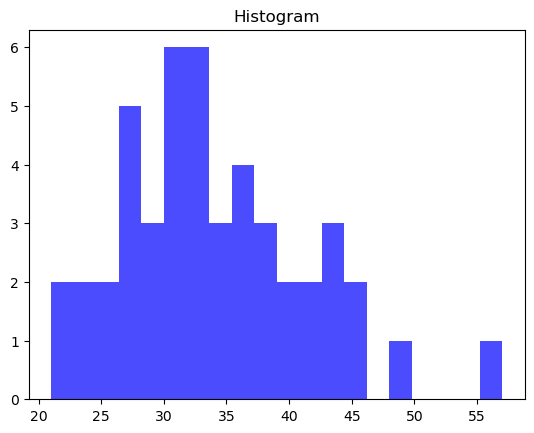

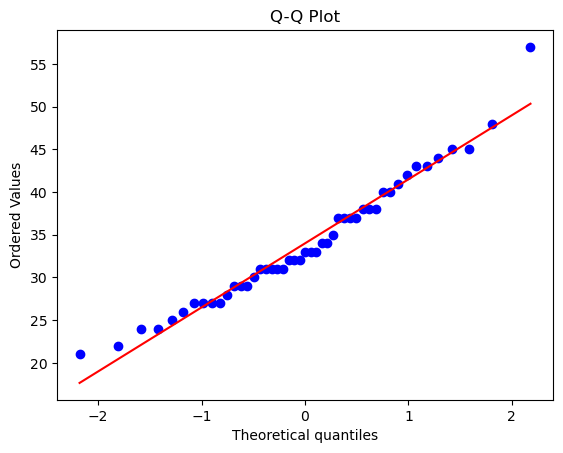

Shapiro-Wilk Test: Stat=0.9669027328491211, P-value=0.20130842924118042
Kolmogorov-Smirnov Test: Stat=0.10671724936691401, P-value=0.6197384921850448


In [36]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Histogram
plt.hist(condition_b, bins=20, alpha=0.7, color='blue')
plt.title('Histogram')
plt.show()

# Q-Q plot
stats.probplot(condition_b, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.show()

# Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(condition_b)
print(f"Shapiro-Wilk Test: Stat={shapiro_stat}, P-value={shapiro_p}")

# Kolmogorov-Smirnov test (comparing against a normal distribution)
ks_stat, ks_p = stats.kstest(condition_b, 'norm', args=(condition_b.mean(), condition_b.std()))
print(f"Kolmogorov-Smirnov Test: Stat={ks_stat}, P-value={ks_p}")

In [25]:
# condition_a

In [26]:
from scipy.stats import ttest_ind

In [27]:
import numpy as np
from scipy.stats import ttest_ind, levene
from statsmodels.stats.weightstats import DescrStatsW
from math import sqrt

# Function to remove outliers
def remove_outliers(data):
    mean = data.mean()
    std_dev = data.std()
    return data[(data > mean - 3 * std_dev) & (data < mean + 3 * std_dev)]

# Remove outliers from both conditions
condition_a_clean = remove_outliers(condition_a)
condition_b_clean = remove_outliers(condition_b)

# Perform Levene's test for equality of variances
levene_stat, levene_p = levene(condition_a_clean, condition_b_clean)
print(f"Levene's test statistic: {levene_stat}")
print(f"Levene's test p-value: {levene_p}")

# Perform independent t-test
t_stat, p_value = ttest_ind(condition_a_clean, condition_b_clean, equal_var=(levene_p >= 0.05))

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpret the p-value
alpha = 0.05

if p_value < alpha:
    print("The difference between the two conditions is statistically significant.")
else:
    print("The difference between the two conditions is not statistically significant.")

# Calculate mean difference
mean_diff = np.mean(condition_a_clean) - np.mean(condition_b_clean)
print(f"Mean difference: {mean_diff}")

# Calculate pooled standard deviation for Cohen's d
n_a = len(condition_a_clean)
n_b = len(condition_b_clean)
std_a = np.std(condition_a_clean, ddof=1)
std_b = np.std(condition_b_clean, ddof=1)
pooled_std = sqrt(((n_a - 1) * std_a**2 + (n_b - 1) * std_b**2) / (n_a + n_b - 2))

# Calculate Cohen's d
cohen_d = mean_diff / pooled_std
print(f"Cohen's d: {cohen_d}")

# Calculate confidence interval for the mean difference
data_a = DescrStatsW(condition_a_clean)
data_b = DescrStatsW(condition_b_clean)
cm = data_a.get_compare(data_b)
ci_low, ci_high = cm.tconfint_diff(usevar='pooled')
print(f"95% confidence interval for the mean difference: ({ci_low}, {ci_high})")

Levene's test statistic: 8.408091806514863
Levene's test p-value: 0.004897752451988146
T-statistic: 2.7956142748333686
P-value: 0.007866746115908076
The difference between the two conditions is statistically significant.
Mean difference: 7.08064516129032
Cohen's d: 0.7294313587604144
95% confidence interval for the mean difference: (2.5871362679117187, 11.574154054668922)


In [28]:
# # Function to remove outliers
# # def remove_outliers(data):
# #     mean = data.mean()
# #     std_dev = data.std()
# #     return data[(data > mean - 3 * std_dev) & (data < mean + 3 * std_dev)]

# # # Remove outliers from both conditions
# # condition_a_clean = remove_outliers(condition_a)
# # condition_b_clean = remove_outliers(condition_b)

# # Perform independent t-test
# t_stat, p_value = ttest_ind(condition_a, condition_b)

# print(f"T-statistic: {t_stat}")
# print(f"P-value: {p_value}")

# # Interpret the p-value
# alpha = 0.05

# if p_value < alpha:
#     print("The difference between the two conditions is statistically significant.")
    
# else:
#     print("The difference between the two conditions is not statistically significant.")

In [29]:
condition_a.mean()

42.1875

In [30]:
condition_b.mean()

34.0

In [40]:
# Mann-Whitney U test
u_stat, p_value = stats.mannwhitneyu(condition_a_clean, condition_b_clean, alternative='two-sided')

print(f"Mann-Whitney U Test: U-statistic={u_stat}, P-value={p_value}")

Mann-Whitney U Test: U-statistic=957.5, P-value=0.011192155619614173
